# Air Quality Classification

Notebook ini bertujuan untuk membangun model klasifikasi yang dapat memprediksi tingkat kualitas udara (**Air Quality**) berdasarkan fitur-fitur lingkungan seperti konsentrasi polutan, suhu, kelembapan, dan faktor demografis.

Dataset yang digunakan berisi 5000 baris data dengan 9 fitur numerik dan 1 variabel kategorikal.

## 1. Import Data

Langkah pertama adalah memuat dataset dan melihat struktur datanya secara umum.

In [ ]:
import pandas as pd

df=pd.read_csv('air_quality.csv')
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


### Deskripsi Fitur

| Fitur | Satuan | Keterangan |
|---|---|---|
| Temperature | °C | Suhu rata-rata wilayah |
| Humidity | % | Kelembapan relatif |
| PM2.5 | µg/m³ | Partikulat halus (diameter < 2.5 µm) |
| PM10 | µg/m³ | Partikulat kasar (diameter < 10 µm) |
| NO2 | ppb | Nitrogen dioksida |
| SO2 | ppb | Sulfur dioksida |
| CO | ppm | Karbon monoksida |
| Proximity_to_Industrial_Areas | km | Jarak ke zona industri terdekat |
| Population_Density | orang/km² | Kepadatan penduduk |

### Target Variable: Air Quality

| Kelas | Keterangan |
|---|---|
| **Good** | Udara bersih, polusi rendah |
| **Moderate** | Kualitas udara cukup, beberapa polutan terdeteksi |
| **Poor** | Polusi terasa, berisiko bagi kelompok sensitif |
| **Hazardous** | Udara sangat tercemar, risiko kesehatan serius |

## 2. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami distribusi data, mendeteksi anomali, dan mengecek kualitas data sebelum masuk ke tahap modeling.

### 2.1 Cek Tipe Data & Informasi Umum

Kita perlu tahu tipe data tiap kolom untuk memastikan tidak ada kolom yang salah tipe (misalnya angka yang terbaca sebagai string).

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


Semua fitur sudah bertipe numerik (`float64`/`int64`) dan target (`Air Quality`) bertipe `object`.

### 2.2 Cek Missing Values & Duplikasi

Missing values bisa menyebabkan error saat training, dan data duplikat bisa menyebabkan bias pada model.

In [3]:
df.isna().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

In [4]:
df.duplicated().sum()

0

Tidak ada missing values maupun data duplikat, jadi kita bisa langsung lanjut tanpa imputasi atau penghapusan baris.

### 2.3 Statistik Deskriptif

Melihat distribusi statistik tiap fitur untuk mendeteksi anomali (nilai negatif, nilai di luar range wajar, dll).

In [5]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


Dari statistik di atas terlihat beberapa anomali:
- **Humidity** memiliki max 128.1% — tidak mungkin karena kelembapan relatif maksimal 100%
- **PM10** memiliki min -0.2 — konsentrasi polutan tidak bisa negatif
- **SO2** memiliki min -6.2 — konsentrasi polutan tidak bisa negatif

Anomali ini perlu di-handle pada tahap data cleaning.

### 2.4 Distribusi Target Variable

In [6]:
df['Air Quality'].unique()

array(['Moderate', 'Good', 'Hazardous', 'Poor'], dtype=object)

In [7]:
df['Air Quality'].value_counts()

Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64

Dataset bersifat **imbalanced**: kelas Good (2000) jauh lebih banyak dari Hazardous (500). Hal ini perlu diperhatikan saat evaluasi model — accuracy saja tidak cukup, kita juga perlu melihat precision, recall, dan F1-score per kelas.

### 2.5 Visualisasi Boxplot

Boxplot digunakan untuk melihat sebaran data dan mendeteksi outlier secara visual pada setiap fitur numerik.

In [8]:
numeric=df.select_dtypes(include=['number']).columns.tolist()
numeric

['Temperature',
 'Humidity',
 'PM2.5',
 'PM10',
 'NO2',
 'SO2',
 'CO',
 'Proximity_to_Industrial_Areas',
 'Population_Density']

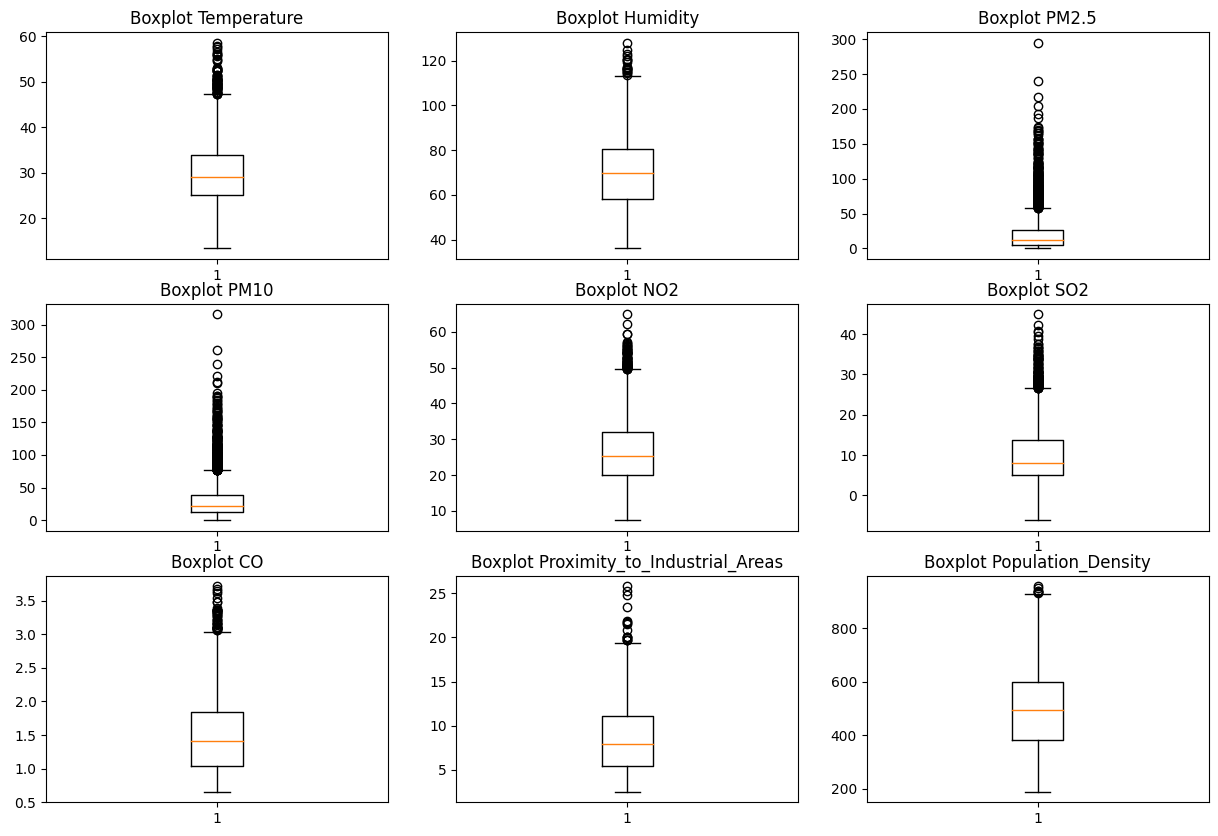

In [9]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(3,3,figsize=(15,10))
ax=ax.flatten()

for i,cols in enumerate(numeric):
    ax[i].boxplot(df[cols])
    ax[i].set_title(f'Boxplot {cols}')

plt.show()

## 3. Data Cleaning

Berdasarkan temuan dari EDA, ada 3 anomali yang perlu diperbaiki. 

### 3.1 Humidity > 100%

Kelembapan relatif secara fisika tidak bisa melebihi 100%. Nilai di atas 100 kemungkinan berasal dari error sensor. Kita clip ke 100.

In [10]:
df[df['Humidity']>100]

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
32,35.4,100.2,20.5,33.2,34.4,11.7,1.85,5.1,440,Poor
53,46.1,100.3,144.0,169.8,42.5,16.1,2.30,7.3,443,Hazardous
82,30.4,101.1,28.6,42.6,39.9,4.0,2.20,6.8,639,Poor
104,44.9,105.8,24.5,47.4,39.9,26.7,2.36,4.0,878,Hazardous
186,31.3,101.5,33.4,52.8,28.7,18.2,1.97,7.6,488,Poor
...,...,...,...,...,...,...,...,...,...,...
4865,41.6,100.7,156.7,166.2,38.7,24.5,1.96,2.8,888,Hazardous
4893,44.0,104.8,22.5,48.3,35.8,12.4,2.03,3.4,627,Hazardous
4911,33.2,109.8,94.1,111.7,46.6,7.4,3.24,3.9,853,Hazardous
4986,35.6,103.8,74.5,93.3,31.8,23.6,2.04,20.8,757,Hazardous


In [11]:
df['Humidity']=df['Humidity'].clip(upper=100)

df['Humidity'].nlargest(5)

32     100.0
53     100.0
82     100.0
104    100.0
186    100.0
Name: Humidity, dtype: float64

Terdapat 195 baris dengan Humidity > 100%. Setelah clipping, nilai maksimum menjadi 100.

### 3.2 PM10 < 0

Konsentrasi partikulat tidak bisa negatif. Kita clip ke 0.

In [12]:
df[df['PM10']<0]

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
22,25.6,58.3,0.4,-0.2,25.3,4.5,0.98,10.0,536,Good


In [13]:
df['PM10']=df['PM10'].clip(lower=0)

df['PM10'].nsmallest(5)

22      0.0
3351    0.0
1712    0.1
1010    0.2
3784    1.0
Name: PM10, dtype: float64

Hanya 1 baris yang memiliki PM10 negatif (-0.2). Setelah clipping menjadi 0.

### 3.3 SO2 < 0

Sama seperti PM10, konsentrasi SO2 tidak bisa negatif. Kita clip ke 0.

In [14]:
df[df['SO2']<0]

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
57,29.0,83.5,31.5,44.4,27.0,-2.8,1.49,5.7,538,Moderate
166,29.3,78.5,14.8,19.2,29.3,-0.4,1.48,8.0,451,Moderate
205,25.9,64.2,1.5,10.3,23.6,-0.4,0.93,11.5,386,Good
351,24.3,44.2,9.5,12.5,18.8,-0.2,0.83,10.6,341,Good
456,26.5,59.9,92.7,98.0,25.4,-0.5,0.92,11.6,485,Good
472,25.0,77.9,2.1,8.6,12.3,-0.3,1.09,14.1,269,Good
508,40.1,62.1,47.7,67.7,31.6,-4.1,2.54,4.9,570,Poor
565,23.9,54.6,0.8,5.8,18.0,-0.6,0.92,13.2,363,Good
805,26.7,66.0,0.5,5.4,20.9,-0.6,0.87,10.1,422,Good
1025,21.8,72.4,4.0,7.5,19.4,-0.3,1.15,12.2,490,Good


In [15]:
df['SO2']=df['SO2'].clip(lower=0)

df['SO2'].nsmallest(5)

57     0.0
166    0.0
205    0.0
351    0.0
456    0.0
Name: SO2, dtype: float64

Terdapat 30 baris dengan SO2 negatif. Setelah clipping, nilai minimum menjadi 0.

## 4. Data Preprocessing

### 4.1 Train-Test Split

Data dibagi 80% training dan 20% testing. Rasio 80/20 adalah standar yang umum digunakan 

`random_state=42` digunakan agar hasil split konsisten dan reproducible.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

x=df.drop(columns=['Air Quality'])
y=df['Air Quality']

# Encode target ke numerik (XGBoost tidak bisa handle string labels)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

x_train,x_test,y_train,y_test=train_test_split(x,y_encoded,test_size=0.2,random_state=42)

# Simpan mapping untuk display
classes = le.classes_.tolist()  # ['Good', 'Hazardous', 'Moderate', 'Poor']
print(f'Classes: {classes}')
print(f'Mapping: {dict(zip(classes, range(len(classes))))}')

Classes: ['Good', 'Hazardous', 'Moderate', 'Poor']
Mapping: {'Good': 0, 'Hazardous': 1, 'Moderate': 2, 'Poor': 3}


### 4.2 Feature Scaling dengan RobustScaler

Kita menggunakan **RobustScaler** karena:
- Dataset memiliki **outlier** yang terlihat jelas dari boxplot (terutama pada PM2.5, PM10, Temperature)
- RobustScaler menggunakan **median dan IQR** (bukan mean dan std), sehingga **tidak terpengaruh outlier**
- Jika menggunakan StandardScaler akan terdistorsi oleh outlier karena mean dan std sensitif terhadap nilai ekstrem

Scaling penting karena beberapa model (seperti Logistic Regression) sensitif terhadap skala fitur yang berbeda-beda. Meskipun Random Forest dan XGBoost tidak membutuhkan scaling, kita tetap menerapkannya secara konsisten di semua pipeline agar perbandingan fair.

## 5. Model Training & Comparison

Kita akan membandingkan **3 model** untuk menemukan model terbaik:

| Model | Tipe | Alasan Dipilih |
|---|---|---|
| **Logistic Regression** | Linear | Baseline model yang simpel dan interpretable. Cocok sebagai titik awal untuk melihat seberapa baik data bisa dipisahkan secara linear. |
| **Random Forest** | Ensemble (Bagging) | Ensemble model berbasis decision tree. Dipilih karena mampu menangkap **hubungan non-linear** antar fitur dan **robust terhadap outlier** (tidak terpengaruh oleh nilai ekstrem pada PM2.5, Temperature, dll). |
| **XGBoost** | Ensemble (Boosting) | Gradient boosting yang biasanya memberikan **performa terbaik pada data tabular**. Dipilih untuk melihat apakah pendekatan boosting (memperbaiki error secara iteratif) bisa mengalahkan bagging (Random Forest). |

Dengan membandingkan 3 pendekatan yang berbeda (linear vs bagging vs boosting), kita bisa mengetahui karakteristik data dan model mana yang paling cocok.

### 5.1 Setup Pipeline

Kita menggunakan `Pipeline` dari scikit-learn supaya preprocessing (scaling) dan modeling tergabung dalam satu objek. Keuntungannya:
- **Tidak ada data leakage** — scaling hanya di-fit pada training data
- **Reproducible** — satu objek untuk predict data baru
- **Clean code** — tidak perlu transform manual saat prediksi

In [17]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

numeric = x_train.columns.tolist()

ct = ColumnTransformer([
    ('rs', RobustScaler(), numeric)
], remainder='passthrough')

# Definisikan 3 model
models = {
    'Logistic Regression': Pipeline([
        ('ct', ct),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('ct', ct),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('ct', ct),
        ('model', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
    ])
}

### 5.2 Training & Evaluasi

Setiap model di-train pada data yang sama, lalu dievaluasi menggunakan:
- **Classification Report** — precision, recall, F1-score per kelas
- **ROC-AUC (One-vs-Rest)** — mengukur kemampuan model membedakan setiap kelas dari kelas lainnya
- **Confusion Matrix** — melihat pola misklasifikasi

 Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.92      0.82      0.87       111
    Moderate       0.96      0.96      0.96       294
        Poor       0.84      0.89      0.86       186

    accuracy                           0.95      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.95      0.95      0.95      1000

ROC-AUC (OVR): 0.9918


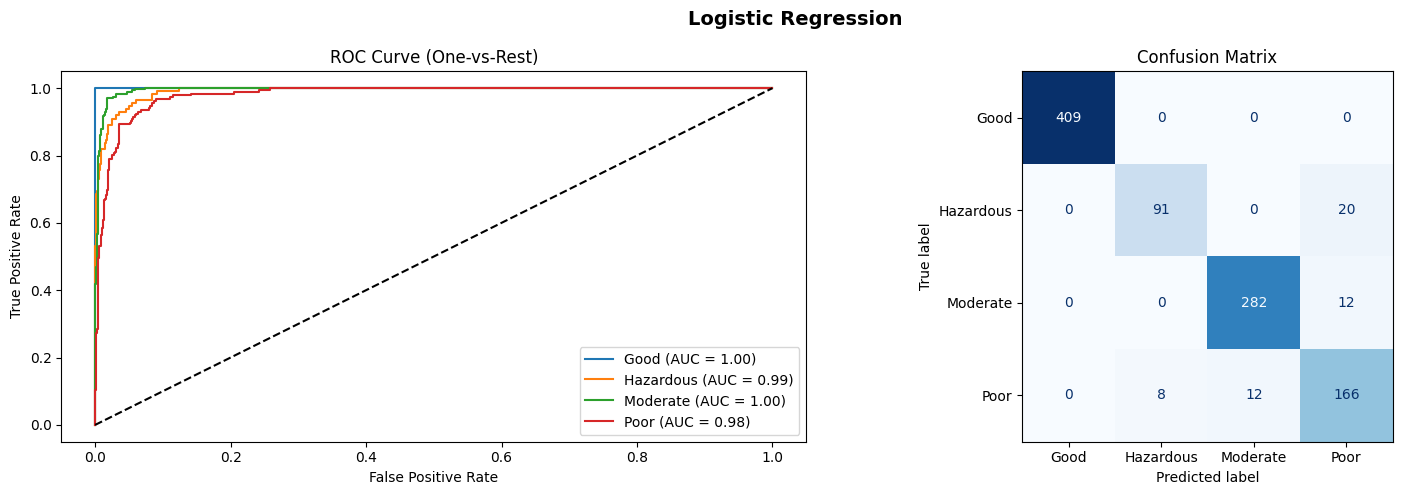


 Random Forest

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.91      0.87      0.89       111
    Moderate       0.97      0.97      0.97       294
        Poor       0.87      0.90      0.89       186

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC (OVR): 0.9941


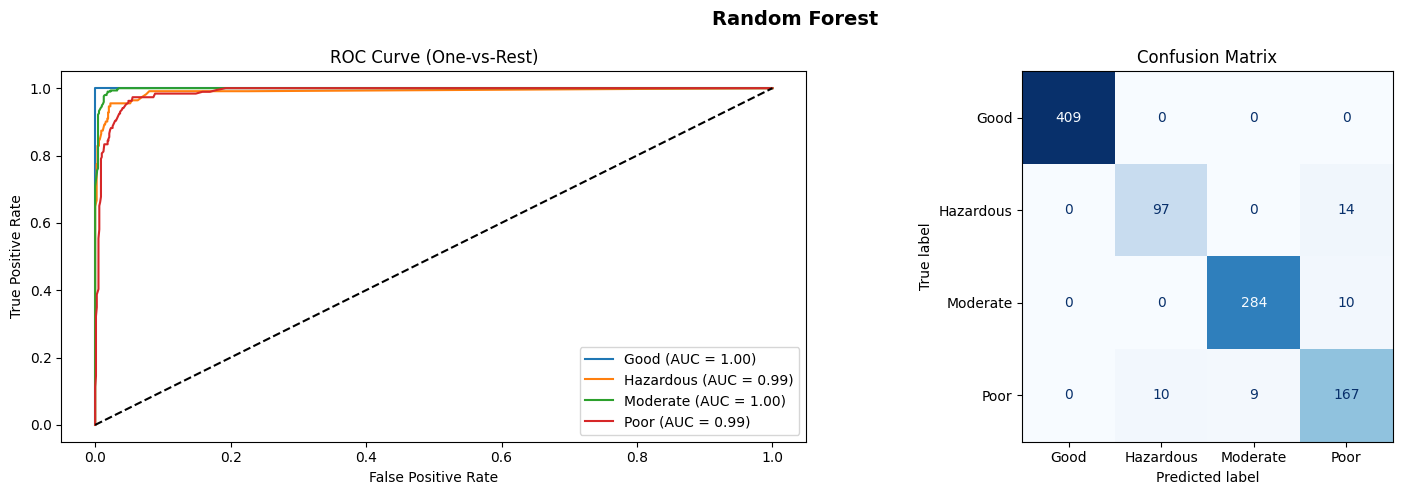


 XGBoost

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.92      0.88      0.90       111
    Moderate       0.97      0.96      0.96       294
        Poor       0.87      0.91      0.89       186

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC (OVR): 0.9950


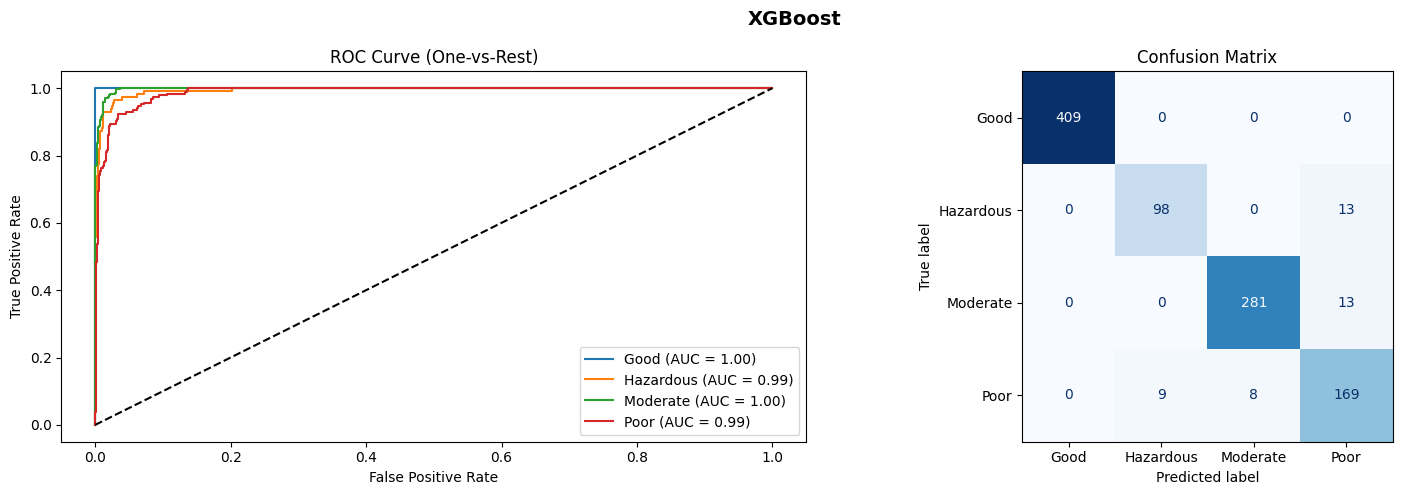

In [18]:
results = {}

for name, pipeline in models.items():
    print(f'={"="*60}')
    print(f' {name}')
    print(f'={"="*60}')

    # Train (y_train sudah numerik dari LabelEncoder)
    pipeline.fit(x_train, y_train)

    # Predict
    y_pred_raw = pipeline.predict(x_test)
    y_proba = pipeline.predict_proba(x_test)

    # Decode ke label string untuk evaluasi
    y_pred = le.inverse_transform(y_pred_raw)
    y_test_str = le.inverse_transform(y_test)

    # Classification Report
    print(f'\nClassification Report:\n{classification_report(y_test_str, y_pred)}')

    # ROC-AUC
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    print(f'ROC-AUC (OVR): {roc:.4f}')

    # Simpan hasil
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'roc_auc': roc,
        'report': classification_report(y_test_str, y_pred, output_dict=True)
    }

    # --- Plot ROC Curve & Confusion Matrix ---
    y_test_bin = label_binarize(y_test_str, classes=classes)
    n_classes = len(classes)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{name}', fontsize=14, fontweight='bold')

    # ROC Curve
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_i = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc_i:.2f})')
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve (One-vs-Rest)')
    axes[0].legend(loc='lower right')

    # Confusion Matrix
    cm = confusion_matrix(y_test_str, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues', ax=axes[1], colorbar=False)
    axes[1].set_title('Confusion Matrix')
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()
    print()

### 5.3 Perbandingan Model

Ringkasan performa ketiga model dalam satu tabel untuk memudahkan perbandingan.

In [19]:
comparison = []
for name, res in results.items():
    r = res['report']
    comparison.append({
        'Model': name,
        'Accuracy': f"{r['accuracy']:.4f}",
        'Macro Precision': f"{r['macro avg']['precision']:.4f}",
        'Macro Recall': f"{r['macro avg']['recall']:.4f}",
        'Macro F1-Score': f"{r['macro avg']['f1-score']:.4f}",
        'ROC-AUC (OVR)': f"{res['roc_auc']:.4f}"
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.set_index('Model', inplace=True)
comparison_df

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,ROC-AUC (OVR)
Model,,,,,
Logistic Regression,0.9480,0.9292,0.9179,0.9226,0.9918
Random Forest,0.9570,0.9375,0.9344,0.9359,0.9941
XGBoost,0.9570,0.9387,0.9368,0.9376,0.9950


Kita menggunakan **Macro Average** (bukan Weighted Average) untuk perbandingan karena dataset ini imbalanced. Macro average memberikan bobot yang sama ke setiap kelas, sehingga performa pada kelas minoritas (Hazardous, Poor) tidak "tenggelam" oleh kelas mayoritas (Good).

### 5.4 Memilih Model Terbaik

In [20]:
best_name = max(results, key=lambda k: float(results[k]['report']['macro avg']['f1-score']))
best_model = models[best_name]

print(f'Model terbaik: {best_name}')
print(f"Macro F1-Score: {results[best_name]['report']['macro avg']['f1-score']:.4f}")
print(f"ROC-AUC: {results[best_name]['roc_auc']:.4f}")

Model terbaik: XGBoost
Macro F1-Score: 0.9376
ROC-AUC: 0.9950


Model terbaik dipilih berdasarkan **Macro F1-Score** karena:
- F1-Score menyeimbangkan precision dan recall
- Macro average memastikan semua kelas (termasuk minoritas) diperlakukan setara
- Pada kasus kualitas udara, salah mengklasifikasi Hazardous sebagai Good (false negative) bisa berbahaya, sehingga recall pada kelas Hazardous penting

## 6. Save Model (Pickle)

Model terbaik disimpan menggunakan `pickle` supaya bisa digunakan kembali tanpa perlu training ulang. File `.pkl` menyimpan seluruh pipeline (scaler + model) sehingga saat prediksi data baru, preprocessing otomatis diterapkan.

In [21]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print('Model berhasil disimpan ke model.pkl')

Model berhasil disimpan ke model.pkl


### Verifikasi Model

Load kembali model yang sudah disimpan dan test dengan sample data untuk memastikan model berfungsi dengan benar.

In [22]:
with open('model.pkl', 'rb') as file:
    load_model = pickle.load(file)

# Test dengan data pertama dari dataset
sample = pd.DataFrame([[29.8, 59.1, 5.2, 17.9, 18.9, 9.2, 1.72, 6.3, 319]], columns=x_train.columns)
y_pred_sample = load_model.predict(sample)
print(f'Input: {sample.values[0]}')
print(f'Prediksi: {le.inverse_transform(y_pred_sample)[0]}')
print(f'Label asli: {df["Air Quality"].iloc[0]}')

Input: [ 29.8   59.1    5.2   17.9   18.9    9.2    1.72   6.3  319.  ]
Prediksi: Moderate
Label asli: Moderate
